In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display
import matplotlib.cm as cm
import tensorflow as tf
import os
import shutil
from tqdm import tqdm
from random import shuffle
import cv2
from glob import glob
from tensorflow.keras import backend as K
import random
import albumentations as A
from sklearn.model_selection import train_test_split, StratifiedKFold
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.applications.efficientnet import *

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
image_dir = Path('/content/drive/MyDrive/flowers')

In [ ]:
# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels
image_df = pd.concat([filepaths, labels], axis=1)

In [ ]:
image_df.head(5)

,Filepath,Label
0,/content/drive/MyDrive/flowers/daisy/128542365...,daisy
1,/content/drive/MyDrive/flowers/daisy/134919596...,daisy
2,/content/drive/MyDrive/flowers/daisy/140737844...,daisy
3,/content/drive/MyDrive/flowers/daisy/104379299...,daisy
4,/content/drive/MyDrive/flowers/daisy/109937100...,daisy


In [ ]:
image_df = image_df.sample(frac=1).reset_index(drop = True)

# Show the result
image_df.head(5)

,Filepath,Label
0,/content/drive/MyDrive/flowers/daisy/558697726...,daisy
1,/content/drive/MyDrive/flowers/tulip/142333484...,tulip
2,/content/drive/MyDrive/flowers/rose/2040986677...,rose
3,/content/drive/MyDrive/flowers/dandelion/25224...,dandelion
4,/content/drive/MyDrive/flowers/dandelion/56442...,dandelion


In [ ]:
image_df.shape

(4317, 2)

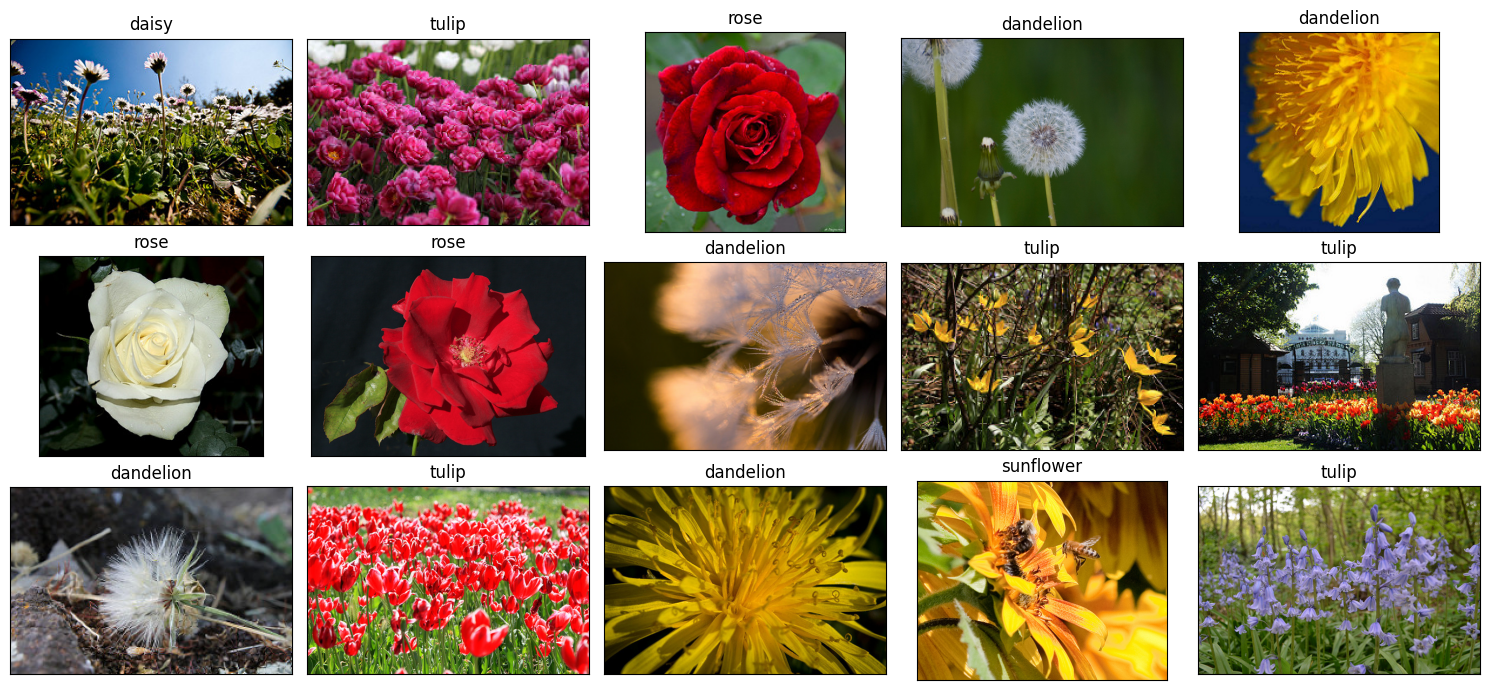

In [ ]:
# Display 20 picture of the dataset with their labels
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(image_df.Filepath[i]))
    ax.set_title(image_df.Label[i])
plt.tight_layout()
plt.show()

In [ ]:
train_df, test_df = train_test_split(image_df, train_size=0.9, shuffle=True, random_state=1)

In [ ]:
train_df.shape

(3885, 2)

In [ ]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [ ]:
train_df.head(5)

,Filepath,Label
3808,/content/drive/MyDrive/flowers/dandelion/33980...,dandelion
1858,/content/drive/MyDrive/flowers/daisy/721595842...,daisy
2275,/content/drive/MyDrive/flowers/rose/1239569841...,rose
1909,/content/drive/MyDrive/flowers/rose/1610031304...,rose
1078,/content/drive/MyDrive/flowers/dandelion/95953...,dandelion


In [ ]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 3108 validated image filenames belonging to 5 classes.
Found 777 validated image filenames belonging to 5 classes.
Found 432 validated image filenames belonging to 5 classes.


In [ ]:
def create_model(input_shape=(224, 224, 3)):

    inputs = Input(input_shape)
    base_model = EfficientNetB1(input_shape=input_shape, include_top=False, classes=5)

    x = base_model(inputs)

    x = GlobalAveragePooling2D()(x)
#     Reduces the spatial dimensions to a single feature vector for each channel.

    x = Dense(56, activation='relu')(x)
    x = Dropout(0.1)(x)

    outputs = Dense(5, activation='sigmoid')(x)

    model = Model(inputs, outputs)

    return model

In [ ]:
K.clear_session()

model = create_model((224, 224, 3))
# model = load_model('models/checkpoint/EfficientNetB0.h5')

metrics = [
    'accuracy',
    'AUC'
]

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=metrics)

In [ ]:
checkpoint_path = 'models/EfficientNetB1/model_224.keras'

callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', patience=15, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.1, patience=5, min_lr=0.000001, verbose=1),
    ModelCheckpoint(
        monitor='val_loss',
        mode='min',
        filepath=checkpoint_path,
        verbose=1,
        save_best_only=True,
        save_weights_only=False  # Save the entire model
    )
]


In [ ]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - AUC: 0.9790 - accuracy: 0.9156 - loss: 0.2557
Epoch 1: val_loss improved from inf to 2.74127, saving model to models/EfficientNetB1/model_224.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 464s 5s/step - AUC: 0.9790 - accuracy: 0.9156 - loss: 0.2556 - val_AUC: 0.5215 - val_accuracy: 0.2239 - val_loss: 2.7413 - learning_rate: 0.0010
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - AUC: 0.9882 - accuracy: 0.9490 - loss: 0.1530
Epoch 2: val_loss improved from 2.74127 to 2.73984, saving model to models/EfficientNetB1/model_224.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 261ms/step - AUC: 0.9882 - accuracy: 0.9490 - loss: 0.1532 - val_AUC: 0.5645 - val_accuracy: 0.2548 - val_loss: 2.7398 - learning_rate: 0.0010
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - AUC: 0.9845 - accuracy: 0.9440 - loss: 0.1940
Epoch 3: val_loss improved from 2.73984 to 1.43614, saving model to models/EfficientNetB1/model_224.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 257ms/ste

In [ ]:
final_training_accuracy = history.history['accuracy'][-1] * 100
final_validation_accuracy = history.history['val_accuracy'][-1] * 100

# Evaluate on Test Dataset
results = model.evaluate(test_images, verbose=0)
test_accuracy = results[1] * 100

# Print Accuracies
print(f"Final Training Accuracy: {final_training_accuracy:.2f}%")
print(f"Final Validation Accuracy: {final_validation_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Final Training Accuracy: 99.74%
Final Validation Accuracy: 93.05%
Test Accuracy: 95.14%
